# CO₂-Booster-Kälteanlage — Expander-Potentialanalyse

Erstellt für: Christof Fischer GmbH. 

---

## Inhaltsverzeichnis

1. Zusammenfassung
2. Randbedingungen & Betriebspunkte
3. Modellbeschreibung & Validierung
4. Ergebnisse — COP-Vergleich
5. Thermodynamische Diagramme ($\log(p)$-$h$)
6. Energiekostenanalyse
7. COP-Sensitivität über Zwischendruck (mit TK-Stufe)

In [10]:
# Setup
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML, publish_display_data
from CoolProp.CoolProp import PropsSI as PSI
from copy import deepcopy

# Hide code cells in HTML/notebook view — output only text/html (no text/plain fallback)
publish_display_data({"text/html": """<style>
div.jp-Cell-inputWrapper { display: none !important; }
div.jp-OutputArea-prompt { display: none !important; }
</style>"""})

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150,
    'font.size': 18, 'axes.titlesize': 20, 'axes.labelsize': 18,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'mathtext.fontset': 'cm',
})

from src.co2_booster import CO2BoosterFlashgasIWT, CO2BoosterParallel
from src.operating_points import (
    OP_SUMMER_NO_PV, OP_SUMMER_WITH_PV,
    OP_TRANSITION_NO_PV, OP_TRANSITION_WITH_PV,
    OP_WRG_NO_PV, OP_WRG_WITH_PV,
    OP_WINTER,
)
from src.plotting import (
    plot_logph_diagram, plot_logph_with_massflow, plot_logph_overlay,
    _draw_logph_background, _draw_model_on_axis, _annotate_state_points,
    _deduplicate_state_points, _annotate_canonical, _COMPONENT_NAMES,
    ECALIA_BLUE, ECALIA_TEAL, ECALIA_RED, ECALIA_ORANGE,
)
from fluprodia import FluidPropertyDiagram

---
## 1. Zusammenfassung

Thermodynamische Simulation einer CO₂-Booster-Kälteanlage ($\dot{Q}_0 \approx 98\,\mathrm{kW}$ NK-Stufe) zur Quantifizierung des Energieeinsparpotentials durch Scroll-Expander. $\eta_\mathrm{s}$ pro Betriebspunkt an BITZER kalibriert → Baseline exakt. Alle Expander-Konfigurationen bei $\mathit{p}_\mathrm{med} = 43\,\mathrm{bar}$ mit IWT vor Expander für fairen Vergleich mit dem PV.

### Kernergebnisse (Hochsommer, transkritisch, Baseline COP = 1.56 = BITZER)

| Konfiguration | $\mathit{p}_\mathrm{med}$ | COP-Verbesserung | Jährl. Ersparnis |
|---|---|---|---|
| MD-Expander | 43 bar | +11 % | ca. 3 400 €/a |
| HD-Expander | 43 bar | +15 % | ca. 4 300 €/a |
| HD + MD Kombination | 43 bar | +26 % | ca. 7 200 €/a |
| Parallelverdichter (BITZER Ref.)† | 43 bar | +20 % | ca. 5 500 €/a† |
| PV + HD-Expander† | 43 bar | +39 % | ca. 9 300 €/a† |

† PV: Im Winter nicht betriebsfähig, in der Übergangszeit am unteren Regelungslimit (30 Hz). Flashgas-Verfügbarkeit unklar → PV-Ersparnisse vermutlich überschätzt. Supermärkte mit Dach-PV haben im Sommer niedrigere Stromkosten, was den PV-Vorteil weiter relativiert (s. Kap. 6).


---
## 2. Randbedingungen & Betriebspunkte

Betriebspunkte von CF (BITZER-Software), 24/7/365 = 8 760 h/a.

| Betriebspunkt | Betriebsart | $\mathit{t}_0$ | $\mathit{p}_\mathrm{high}$ | $\mathit{t}_\mathrm{GC/kond}$ | $\mathit{p}_\mathrm{med}$ | $\mathrm{COP}_\mathrm{BITZER}$ | Std./a |
|---|---|---|---|---|---|---|---|
| Hochsommer | Transkritisch | −10 °C | 93.7 bar | 38 °C | 38 bar | 1.56 | 800 |
| Übergang | Subkritisch | −10 °C | 65.3 bar\* | 27 °C | 38 bar | 2.97 | 3 160 |
| WRG | Transkritisch | −10 °C | 85.0 bar | 25 °C | 38 bar | 2.36 | 2 000 |
| Winter | Subkritisch | −10 °C | 47.9 bar\* | 17 °C | 38 bar | 4.54 | 2 800 |

\* Kondensationsdruck bei subkritischem Betrieb

### Stundenverteilung (eigene Abschätzung)

| Temperaturbereich | Betriebspunkt | Stunden |
|---|---|---|
| > 30 °C | Hochsommer | 800 |
| 15–30 °C | Übergang | 3 160 |
| 5–15 °C | WRG | 2 000 |
| < 5 °C | Winter | 2 800 |

Basis: typische Temperatur-Häufigkeitsverteilung Süddeutscher Raum. Für ein konkretes Projekt sollte die Verteilung aus TRY-Daten oder der Gebäudeleittechnik abgeleitet werden.


### Simulationsparameter

| Parameter | Wert |
|---|---|
| NK-Kompressor $\eta_\mathrm{s}$ | pro OP kalibriert (0.66–0.69), s. Kap. 3 |
| PV-Kompressor $\eta_\mathrm{s}$ | = NK (nicht separat kalibrierbar, s. Kap. 3) |
| Expander $\eta_\mathrm{exp}$ | 0.70 (konservativ) |
| Strompreis (Netzbezug) | 0.22 €/kWh |
| Strompreis (Dach-PV) | saisonabhängig: 0.16–0.22 €/kWh |

### Annahmen

- Betriebspunkte zeitlich konstant (keine Teillast, keine Übergänge).
- Vergleich bei gleicher Kälteleistung $\dot{Q}_0 \approx 98\,\mathrm{kW}$ — Einsparung rein aus COP-Unterschied.
- Alle Expander-Konfigurationen bei $\mathit{p}_\mathrm{med} = 43\,\mathrm{bar}$ (= PV-Mitteldruck) mit IWT vor Expander für fairen Vergleich.
- PV kann nur 30–70 Hz regeln; im Winter nicht betriebsfähig, in der Übergangszeit durchgängig bei 30 Hz.
- Reine NK-Betrachtung (TK-Stufe nicht modelliert, s. aber COP-Sensitivität Kap. 7).

In [11]:
# Modelle berechnen — kalibrierte η_s pro Betriebspunkt (NK-Kompressor)
ETA_S_CALIBRATED = {
    "Hochsommer": 0.691,   # π ≈ 3.5 — BITZER COP 1.56
    "Übergang":   0.684,   # π ≈ 2.5 — BITZER COP 2.97
    "WRG-Modus":  0.679,   # π ≈ 3.2 — BITZER COP 2.36
    "Winter":     0.655,   # π ≈ 2.0 — BITZER COP 4.54
}

ETA_E = 0.70
HOURS_PER_YEAR = {"Hochsommer": 800, "Übergang": 3160, "WRG-Modus": 2000, "Winter": 2800}

# Strompreise
ELECTRICITY_PRICE_FLAT = 0.22  # €/kWh — reiner Netzbezug

# Szenario "Supermarkt mit Dach-PV": PV-Eigenverbrauch senkt effektive Kosten im Sommer
# Annahme: PV-LCOE ≈ 0.07 €/kWh; Eigenverbrauchsanteil saisonabhängig
ELECTRICITY_PRICE_PER_OP = {
    "Hochsommer": 0.16,  # ~40 % PV-Eigenverbrauch
    "Übergang":   0.18,  # ~25 % PV
    "WRG-Modus":  0.20,  # ~15 % PV
    "Winter":     0.22,  # kaum PV → voller Netzbezug
}

# Alle Expander-Konfigurationen bei p_med = 43 bar und IWT vor Expander (before_exp)
# für einen fairen Vergleich mit dem PV, der ebenfalls bei 43 bar arbeitet.
IWT_POSITION = "before_exp"

configs = {
    "Baseline (V+V)":     {"cls": CO2BoosterFlashgasIWT, "kwargs": {}},
    "MD-Exp":             {"cls": CO2BoosterFlashgasIWT,
                           "kwargs": {"expansion_device_fg": "expander",
                                      "iwt_position": IWT_POSITION},
                           "p_med_override": 43.0},
    "HD-Exp":             {"cls": CO2BoosterFlashgasIWT,
                           "kwargs": {"expansion_device_hp": "expander",
                                      "iwt_position": IWT_POSITION},
                           "p_med_override": 43.0},
    "HD+MD Exp":          {"cls": CO2BoosterFlashgasIWT,
                           "kwargs": {"expansion_device_hp": "expander",
                                      "expansion_device_fg": "expander",
                                      "iwt_position": IWT_POSITION},
                           "p_med_override": 43.0},
    "PV (Parallel)":      {"cls": CO2BoosterParallel, "kwargs": {}},
    "PV + HD-Exp":        {"cls": CO2BoosterParallel,
                           "kwargs": {"expansion_device_hp": "expander"}},
}

# WICHTIG: PV-Konfigurationen verwenden jeweils die PV-spezifischen Betriebspunkte
# von BITZER (anderer p_medium, anderer Kompressor). Ohne PV → flashgas-OP (p_med=38 bar).
test_ops = {
    "Hochsommer": {"flashgas": OP_SUMMER_NO_PV, "pv": OP_SUMMER_WITH_PV},
    "Übergang":   {"flashgas": OP_TRANSITION_NO_PV, "pv": OP_TRANSITION_WITH_PV},
    "WRG-Modus":  {"flashgas": OP_WRG_NO_PV, "pv": OP_WRG_WITH_PV},
    "Winter":     {"flashgas": OP_WINTER, "pv": OP_WINTER},
}

# PV kann im Winter nicht betrieben werden (laut CF: 0 % Regelung).
PV_UNAVAILABLE_OPS = {"Winter"}

all_results = {}
all_models = {}

for cfg_name, cfg_def in configs.items():
    all_results[cfg_name] = {}
    for op_name, ops in test_ops.items():
        cls = cfg_def["cls"]
        is_pv = (cls == CO2BoosterParallel)

        if is_pv and op_name in PV_UNAVAILABLE_OPS:
            all_results[cfg_name][op_name] = None
            continue

        op = ops["pv"] if is_pv else ops["flashgas"]

        p_med_ovr = cfg_def.get("p_med_override")
        if p_med_ovr:
            op = deepcopy(op)
            op.p_medium = p_med_ovr

        eta_s = ETA_S_CALIBRATED[op_name]

        try:
            kw = {**cfg_def["kwargs"],
                  "compressor_efficiency": eta_s,
                  "expander_efficiency": ETA_E}
            model = cls(**kw)
            model.setup_network(iterinfo=False)
            model.set_boundary_conditions(op=op)
            model.solve()
            if model.converged:
                cop = model.calculate_cop_cooling()
                power = model.get_power_breakdown()
                P_comp = sum(d['P_kW'] for d in power.values() if d['type'] == 'compressor')
                P_exp  = sum(d['P_kW'] for d in power.values() if d['type'] == 'expander')
                all_results[cfg_name][op_name] = {
                    "cop": cop, "P_comp": P_comp, "P_exp": P_exp, "P_net": P_comp + P_exp,
                }
                all_models[(cfg_name, op_name)] = model
        except Exception:
            all_results[cfg_name][op_name] = None

---
## 3. Modellvalidierung

$\eta_\mathrm{s}$ wurde pro Betriebspunkt an BITZER-Baseline kalibriert (NK, $\mathit{p}_\mathrm{med} = 38\,\mathrm{bar}$) → Baseline-COPs stimmen exakt überein.

Expander-Konfigurationen laufen bei $\mathit{p}_\mathrm{med} = 43\,\mathrm{bar}$ (= PV-Mitteldruck) mit IWT vor Expander für einen fairen Vergleich. $\eta_\mathrm{s}$ wurde bei 38 bar kalibriert → bei 43 bar verschobenes Druckverhältnis, aber Effekt auf relative Vergleiche gering.

Für PV-Konfigurationen wird derselbe $\eta_\mathrm{s}$ verwendet. Systematische Abweichungen entstehen durch den anderen Kompressor (PV-spezifisch). Die PV-Abweichungen (s. Tabelle) beeinflussen den relativen Vergleich Expander vs. PV nur geringfügig.

In [12]:
# --- Kalibrierung & Validierung ---
bitzer_cops = {"Hochsommer": 1.56, "Übergang": 2.97, "WRG": 2.36, "Winter": 4.54}
bitzer_cops_pv = {"Hochsommer": 1.85, "Übergang": 3.43, "WRG": 2.48}

# Baseline-Validierung (kalibrierte η_s)
val_rows = []
for op_name, cop_b in bitzer_cops.items():
    r = all_results["Baseline (V+V)"].get(op_name)
    if r is None:
        # try WRG-Modus key for backward compat
        r = all_results["Baseline (V+V)"].get("WRG-Modus") if op_name == "WRG" else None
    # find calibrated eta_s
    eta_key = "WRG-Modus" if op_name == "WRG" else op_name
    cop_t = r["cop"] if r else None
    delta = (cop_t - cop_b) / cop_b * 100 if cop_t else None
    val_rows.append({
        "Betriebspunkt": op_name,
        "$\\eta_\\mathrm{s}$ (NK)": f"{ETA_S_CALIBRATED[eta_key]:.3f}",
        "COP BITZER": f"{cop_b:.2f}",
        "COP TESPy": f"{cop_t:.2f}" if cop_t else "—",
        "Δ [%]": f"{delta:+.2f}" if delta is not None else "—",
    })

df_val = pd.DataFrame(val_rows)
display(Markdown("**Baseline-Validierung: kalibrierter $\\eta_\\mathrm{s}$ pro Betriebspunkt**\n\n" + df_val.to_markdown(index=False)))

# PV-Validierung (gleicher η_s wie Baseline — nicht separat kalibriert)
val_rows_pv = []
for op_name, cop_b in bitzer_cops_pv.items():
    r = all_results["PV (Parallel)"].get(op_name)
    if r is None:
        r = all_results["PV (Parallel)"].get("WRG-Modus") if op_name == "WRG" else None
    eta_key = "WRG-Modus" if op_name == "WRG" else op_name
    cop_t = r["cop"] if r else None
    delta = (cop_t - cop_b) / cop_b * 100 if cop_t else None
    val_rows_pv.append({
        "Betriebspunkt": op_name,
        "$\\eta_\\mathrm{s}$ (NK)": f"{ETA_S_CALIBRATED[eta_key]:.3f}",
        "COP BITZER (PV)": f"{cop_b:.2f}",
        "COP TESPy (PV)": f"{cop_t:.2f}" if cop_t else "—",
        "Δ [%]": f"{delta:+.1f}" if delta is not None else "—",
    })

df_val_pv = pd.DataFrame(val_rows_pv)
display(Markdown("**PV-Validierung: gleicher $\\eta_\\mathrm{s}$ wie Baseline**\n\n" + df_val_pv.to_markdown(index=False)))

**Baseline-Validierung: kalibrierter $\eta_\mathrm{s}$ pro Betriebspunkt**

| Betriebspunkt   |   $\eta_\mathrm{s}$ (NK) |   COP BITZER |   COP TESPy |   Δ [%] |
|:----------------|-------------------------:|-------------:|------------:|--------:|
| Hochsommer      |                    0.691 |         1.56 |        1.56 |    0.02 |
| Übergang        |                    0.684 |         2.97 |        2.97 |    0.03 |
| WRG             |                    0.679 |         2.36 |        2.36 |   -0.06 |
| Winter          |                    0.655 |         4.54 |        4.54 |    0.02 |

**PV-Validierung: gleicher $\eta_\mathrm{s}$ wie Baseline**

| Betriebspunkt   |   $\eta_\mathrm{s}$ (NK) |   COP BITZER (PV) |   COP TESPy (PV) |   Δ [%] |
|:----------------|-------------------------:|------------------:|-----------------:|--------:|
| Hochsommer      |                    0.691 |              1.85 |             1.88 |     1.4 |
| Übergang        |                    0.684 |              3.43 |             3.31 |    -3.4 |
| WRG             |                    0.679 |              2.48 |             2.54 |     2.6 |

---
## 4. COP-Vergleich — Alle Konfigurationen

In [ ]:
# COP-Tabelle
baseline_name = "Baseline"
# Display names for operating points (shortened for table width)
OP_DISPLAY = {"Hochsommer": "Hochsommer", "Übergang": "Übergang",
              "WRG-Modus": "WRG", "Winter": "Winter"}
cop_rows = []
for cfg_name in configs:
    is_pv = configs[cfg_name]["cls"] == CO2BoosterParallel
    label = cfg_name + ("†" if is_pv else "")
    row = {"Konfiguration": label}
    for op_name in test_ops:
        disp = OP_DISPLAY[op_name]
        r = all_results[cfg_name].get(op_name)
        r_base = all_results[baseline_name].get(op_name)
        if r and r_base:
            cop = r["cop"]
            delta = (cop - r_base["cop"]) / r_base["cop"] * 100
            row[f"COP {disp}"] = f"{cop:.2f}"
            row[f"Δ {disp} [%]"] = f"{delta:+.1f}"
        else:
            row[f"COP {disp}"] = "—"
            row[f"Δ {disp} [%]"] = "—"
    cop_rows.append(row)

df_cop = pd.DataFrame(cop_rows)
display(Markdown("**COP-Vergleich: Alle Konfigurationen × Betriebspunkte**\n\n" + df_cop.to_markdown(index=False)))
display(Markdown("† PV: Thermodynamisches Maximum bei voller Verfügbarkeit (Einschränkungen s. Kap. 1)."))

**COP-Vergleich: Alle Konfigurationen × Betriebspunkte**

| Konfiguration   |   COP Hochsommer |   Δ Hochsommer [%] |   COP Übergang |   Δ Übergang [%] |   COP WRG |   Δ WRG [%] | COP Winter   | Δ Winter [%]   |
|:----------------|-----------------:|-------------------:|---------------:|-----------------:|----------:|------------:|:-------------|:---------------|
| Baseline (V+V)  |             1.56 |                0   |           2.97 |              0   |      2.36 |         0   | 4.54         | +0.0           |
| MD-Exp          |             1.73 |               10.8 |           3.15 |              5.9 |      2.46 |         4.3 | 4.65         | +2.5           |
| HD-Exp          |             1.79 |               15   |           3.15 |              5.9 |      2.53 |         7.4 | 4.64         | +2.2           |
| HD+MD Exp       |             1.96 |               25.9 |           3.32 |             11.8 |      2.63 |        11.6 | 4.74         | +4.5           |
| PV (Parallel)†  |             1.88 |               20.2 |           3.31 |             11.6 |      2.54 |         7.9 | —            | —              |
| PV + HD-Exp†    |             2.17 |               38.8 |           3.51 |             18   |      2.77 |        17.3 | —            | —              |

† PV: Thermodynamisches Maximum bei voller Verfügbarkeit (Einschränkungen s. Kap. 1).

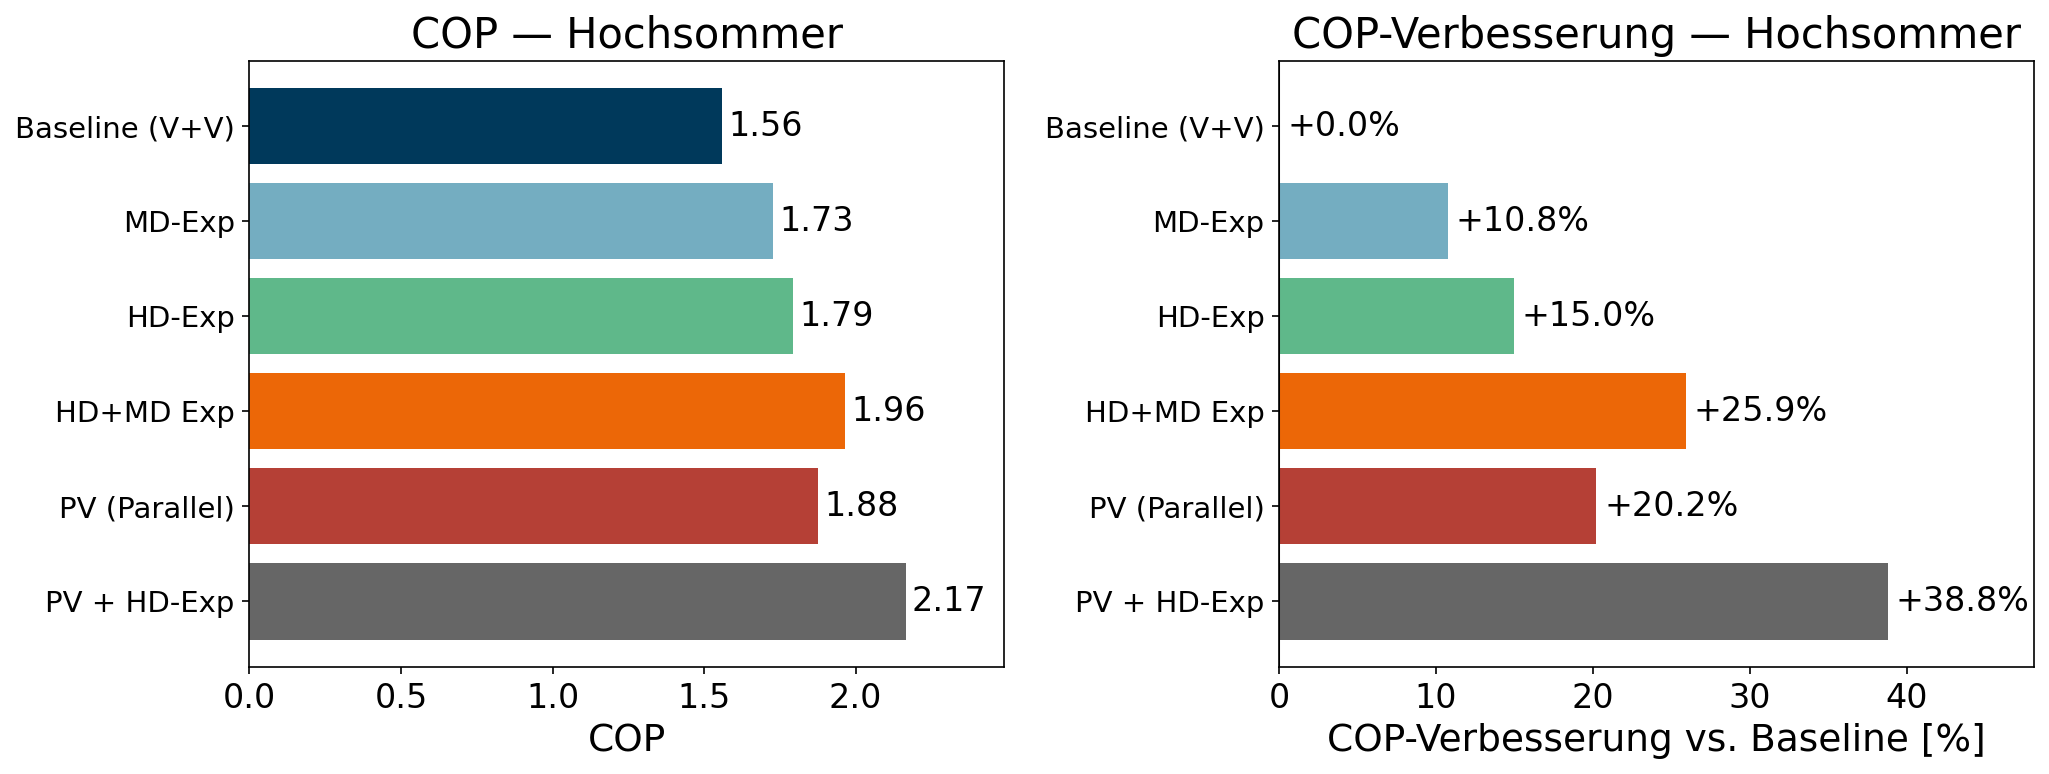

In [14]:
# COP-Balkendiagramm (Hochsommer)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
cfg_names = list(configs.keys())
colors_all = [ECALIA_BLUE, ECALIA_TEAL, '#5fb88a', ECALIA_ORANGE, ECALIA_RED, '#666666', '#333333']
# Sicherstellen, dass genug Farben da sind
while len(colors_all) < len(cfg_names):
    colors_all.append('#888888')

cops_hs = []
for c in cfg_names:
    r = all_results[c].get("Hochsommer")
    cops_hs.append(r["cop"] if r else 0)

bars = ax1.barh(range(len(cfg_names)), cops_hs, color=colors_all[:len(cfg_names)])
for bar, val in zip(bars, cops_hs):
    if val > 0:
        ax1.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                f"{val:.2f}", va='center', fontsize=16)
ax1.set_yticks(range(len(cfg_names)))
ax1.set_yticklabels(cfg_names, fontsize=14)
ax1.set_xlabel("COP")
ax1.set_title("COP — Hochsommer")
ax1.invert_yaxis()
ax1.margins(x=0.15)  # mehr Platz am unteren Balken

baseline_hs = all_results["Baseline (V+V)"]["Hochsommer"]["cop"]
deltas = [(c - baseline_hs)/baseline_hs*100 if c > 0 else 0 for c in cops_hs]
bars2 = ax2.barh(range(len(cfg_names)), deltas, color=colors_all[:len(cfg_names)])
for bar, val in zip(bars2, deltas):
    ax2.text(max(bar.get_width(),0)+0.5, bar.get_y()+bar.get_height()/2,
            f"{val:+.1f}%", va='center', fontsize=16)
ax2.set_yticks(range(len(cfg_names)))
ax2.set_yticklabels(cfg_names, fontsize=14)
ax2.set_xlabel("COP-Verbesserung vs. Baseline [%]")
ax2.set_title("COP-Verbesserung — Hochsommer")
ax2.invert_yaxis()
ax2.margins(x=0.24)
ax2.axvline(x=0, color='black', linewidth=0.5)
fig.tight_layout()
plt.show()

---
## 5. Thermodynamische Diagramme

$\log(p)$-$h$-Vergleich: Baseline (38 bar) vs. Vergleichskonfiguration (43 bar, Hochsommer). Expander-Konfigurationen nutzen die überhitzte Topologie (IWT vor Expander): Das Flashgas wird im IWT auf Mitteldruckniveau so weit überhitzt, dass es nach Expansion am Saugdruckniveau dieselbe Überhitzung aufweist wie die Baseline-Saugseite — maximale Unterkühlung, kein Kondensationsrisiko im Expander.

> **Hinweis IWT-Fläche:** Sollte der IWT für die benötigte Überhitzung zu groß werden, kann alternativ nach Expansion wärmegetauscht werden. Dann wird das Flashgas bei teils flüssiger Phase im IWT erwärmt — hydraulisch einfacher, aber geringfügig niedrigerer COP (ca. −0.5 %).

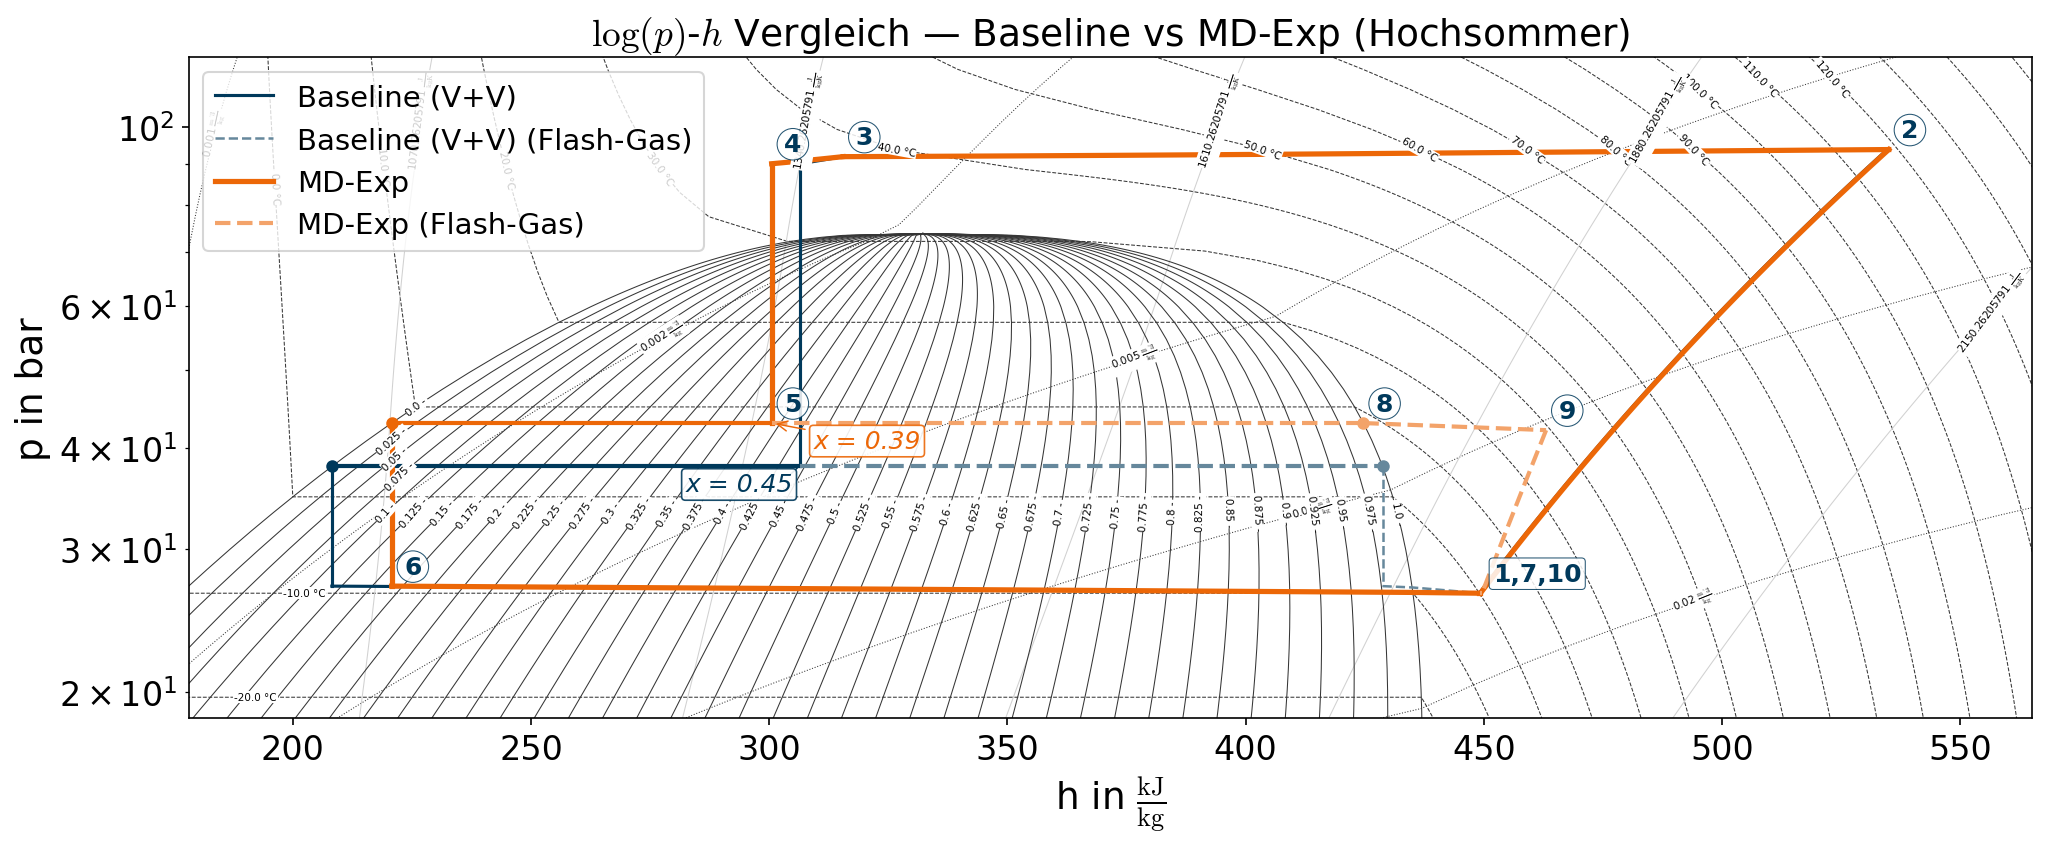

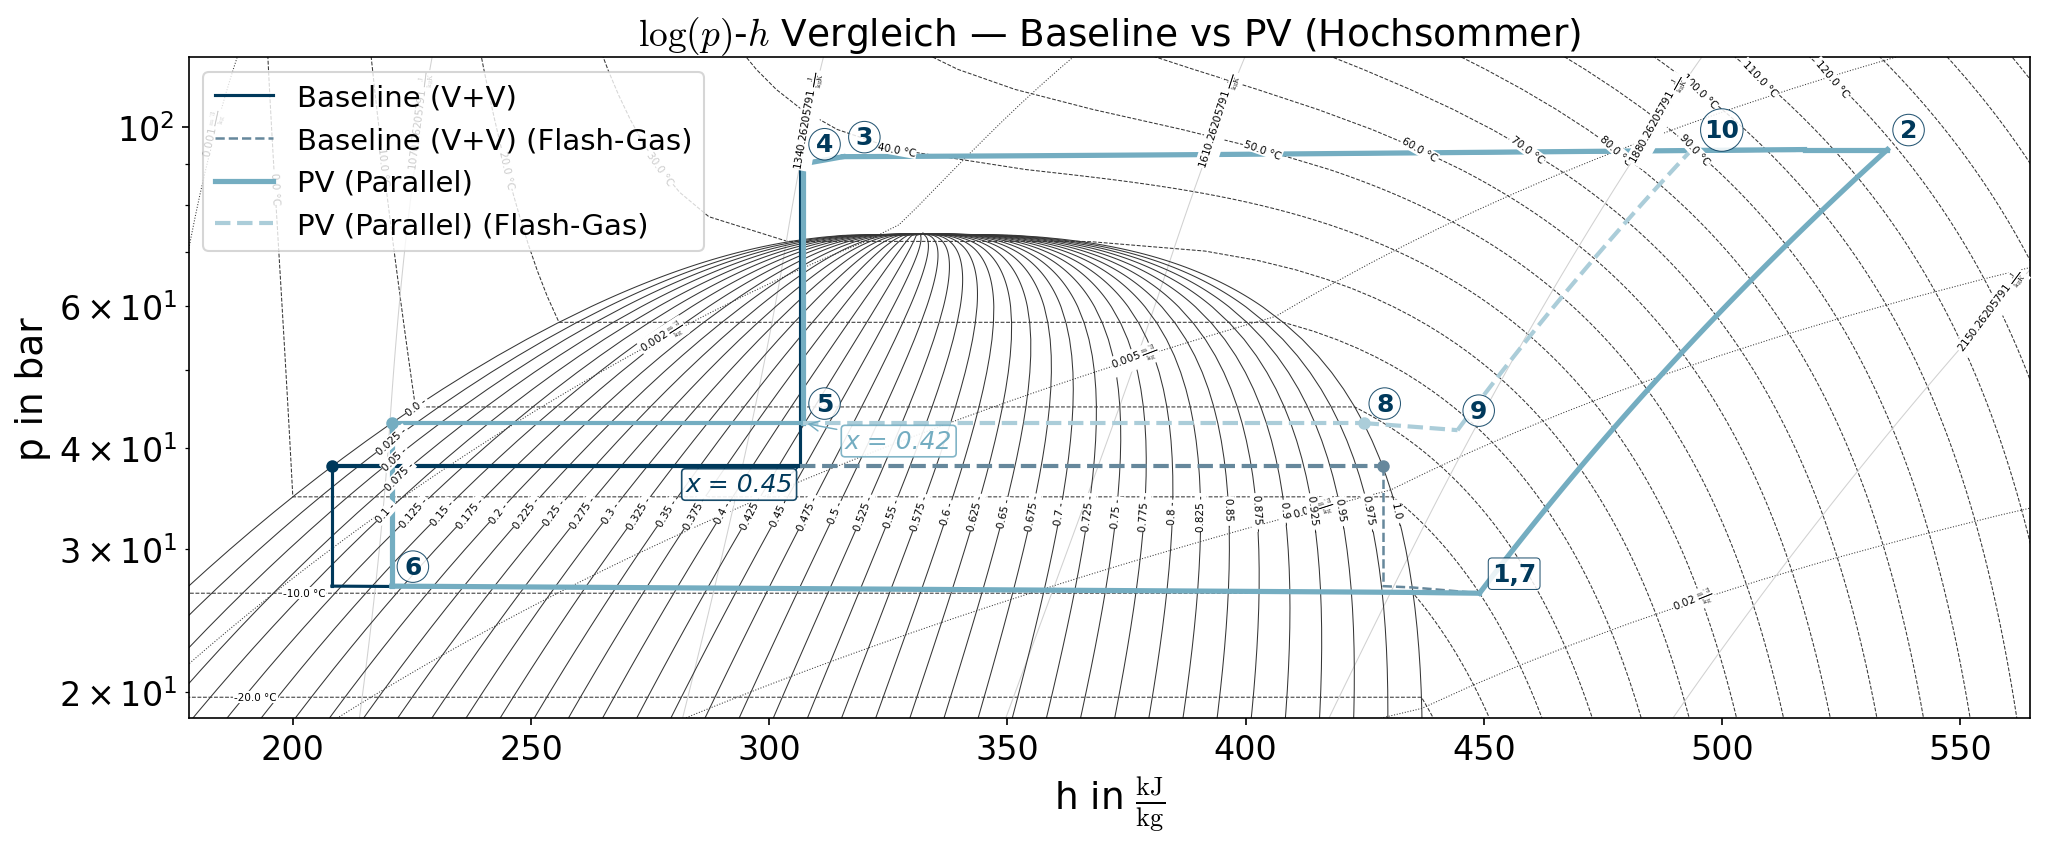

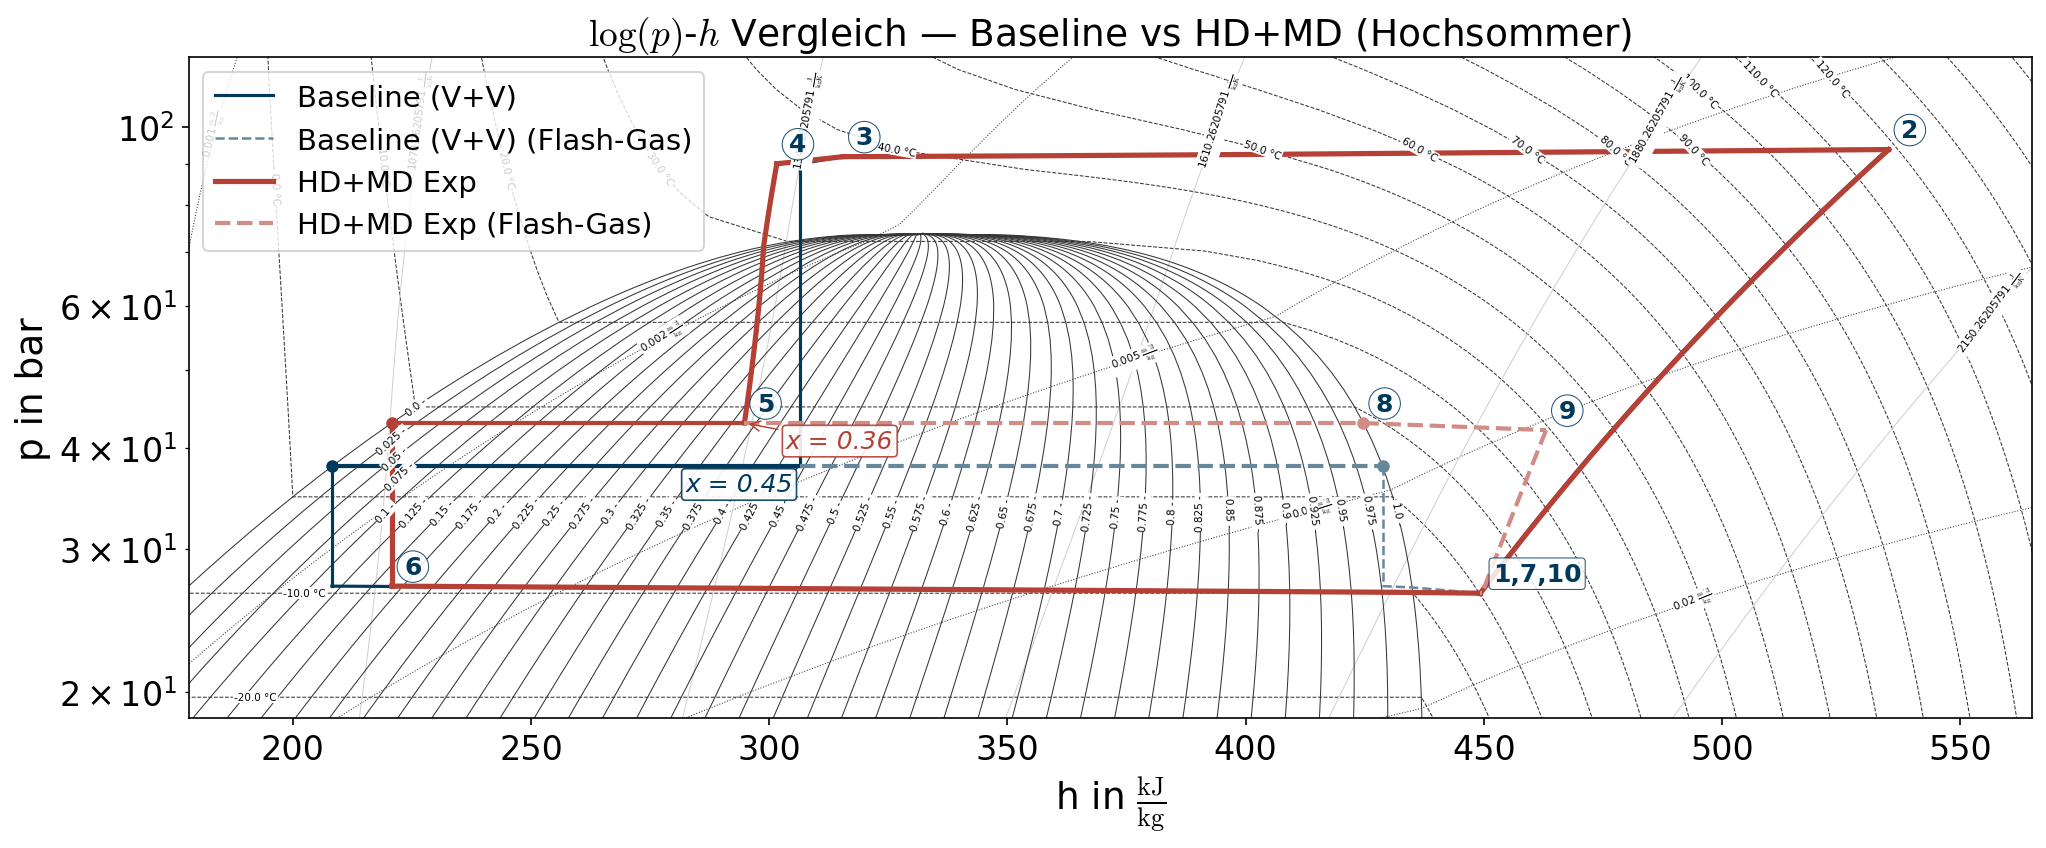

**Zustandspunkte — Vergleichskonfigurationen (Hochsommer), h [kJ/kg], p [bar]**

|   Nr. | Zustandspunkt            |   MD h |   MD p |   PV h |   PV p |   HD+MD h |   HD+MD p |
|------:|:-------------------------|-------:|-------:|-------:|-------:|----------:|----------:|
|     1 | Kompr. Eintritt          |  449.3 |   26.5 |  449.1 |   26.5 |     449.3 |      26.5 |
|     2 | Kompr. Austritt          |  535   |   93.7 |  534.7 |   93.7 |     535   |      93.7 |
|     3 | GK Austritt / IWT (warm) |  315.5 |   91.8 |  315.5 |   91.8 |     315.5 |      91.8 |
|     4 | IWT (warm) Austritt      |  300.5 |   90   |  307.2 |   90   |     301.6 |      90   |
|     5 | HD-Exp. Austritt         |  300.5 |   43   |  307.2 |   43   |     294.8 |      43   |
|     6 | Verdampfer Eintritt      |  220.8 |   27   |  220.8 |   27   |     220.8 |      27   |
|     7 | Verdampfer Austritt      |  449.1 |   26.5 |  449.1 |   26.5 |     449.1 |      26.5 |
|     8 | Sammler Dampf            |  424.7 |   43   |  424.7 |   43   |     424.7 |      43   |
|     9 | IWT (kalt) Austritt      |  463.1 |   42.1 |  444.5 |   42.1 |     463.1 |      42.1 |
|    10 | Exp./Ventil Austritt     |  449.6 |   26.5 |  493.6 |   93.7 |     449.6 |      26.5 |

In [15]:

# log(p)-h Overlay mit kanonisch nummerierten Zustandspunkten

overlay_configs = [
    ("Baseline vs MD-Exp", "Baseline (V+V)", "MD-Exp",        ECALIA_BLUE, ECALIA_ORANGE),
    ("Baseline vs PV",     "Baseline (V+V)", "PV (Parallel)", ECALIA_BLUE, ECALIA_TEAL),
    ("Baseline vs HD+MD",  "Baseline (V+V)", "HD+MD Exp",     ECALIA_BLUE, ECALIA_RED),
]

panel_legends = {}

for title, cfg1, cfg2, color1, color2 in overlay_configs:
    m1 = all_models.get((cfg1, "Hochsommer"))
    m2 = all_models.get((cfg2, "Hochsommer"))
    if m1 is None or m2 is None:
        print(f"Modell nicht verfügbar: {cfg2}")
        continue

    fig, ax = plt.subplots(figsize=(14, 6))

    diagram = FluidPropertyDiagram('CO2')
    diagram.set_unit_system(T='°C', p='bar', h='kJ/kg')

    h_vals, p_vals = [], []
    for mdl in [m1, m2]:
        for k, data in mdl.get_results().items():
            dp = diagram.calc_individual_isoline(**data)
            h_vals.extend(dp['h']); p_vals.extend(dp['p'])
        for st in mdl.get_state_points().values():
            h_vals.append(st['h']); p_vals.append(st['p'])

    _draw_logph_background(diagram, fig, ax,
                           min(h_vals)-30, max(h_vals)+30,
                           min(p_vals)*0.7, max(p_vals)*1.3)
    _draw_model_on_axis(m1, diagram, ax, color1, linewidth=1.5, label=cfg1)
    _draw_model_on_axis(m2, diagram, ax, color2, linewidth=2.5, label=cfg2)

    # Kanonisch nummerierte Zustandspunkte (m2) + x-Annotation mit Farben beider Modelle
    canon_tuples = _annotate_canonical(m2, ax, fontsize=12, x_color=color2)
    panel_legends[title] = (cfg2, canon_tuples)

    # Vapor Quality bei Zustand 5 auch für Baseline (m1) anzeigen — in Baseline-Farbe
    try:
        states1 = m1.get_state_points()
        canon1 = m1.get_canonical_state_points()
        conn5_m1 = next((c for n, c, _ in canon1 if n == 5), None)
        if conn5_m1 and conn5_m1 in states1:
            st5 = states1[conn5_m1]
            x1 = st5.get('x')
            if x1 is None or x1 < 0 or x1 > 1:
                from CoolProp.CoolProp import PropsSI
                x1 = PropsSI("Q", "H", st5['h'] * 1e3, "P", st5['p'] * 1e5, "CO2")
            if x1 is not None and 0 <= x1 <= 1:
                ax.annotate(
                    f"x = {x1:.2f}", (st5['h'], st5['p']),
                    textcoords="offset points", xytext=(-55, -12),
                    fontsize=12, fontstyle="italic", color=color1,
                    arrowprops=dict(arrowstyle='->', color=color1, lw=0.7),
                    bbox=dict(boxstyle="round,pad=0.15", fc="white",
                              ec=color1, alpha=0.9, lw=0.8),
                    zorder=10,
                )
    except Exception:
        pass

    ax.set_title(f"$\\log(p)$-$h$ Vergleich — {title} (Hochsommer)", fontsize=18)
    ax.legend(fontsize=14)
    fig.tight_layout()
    plt.show()

# Zustandspunkt-Tabelle — flaches Format für sauberen LaTeX-Export
first_cfg = list(panel_legends.keys())[0]
desc_map = {num: desc for num, desc, _, _ in panel_legends[first_cfg][1]}

# Short config names for table columns
_CFG_SHORT = {"MD-Exp": "MD", "PV (Parallel)": "PV", "HD+MD Exp": "HD+MD"}

# Flache Tabelle: Nr. | Zustandspunkt | cfg1 h | cfg1 p | cfg2 h | cfg2 p | ...
flat_rows = []
all_nums = sorted({num for _, (_, tuples) in panel_legends.items() for num, _, _, _ in tuples})
for num in all_nums:
    row = {"Nr.": num, "Zustandspunkt": desc_map.get(num, "")}
    for panel_title, (cfg2_name, canon_tuples) in panel_legends.items():
        short = _CFG_SHORT.get(cfg2_name, cfg2_name)
        lookup = {n: (h, p) for n, _, h, p in canon_tuples}
        if num in lookup:
            h_val, p_val = lookup[num]
            row[f"{short} h"] = f"{h_val:.1f}"
            row[f"{short} p"] = f"{p_val:.1f}"
        else:
            row[f"{short} h"] = "—"
            row[f"{short} p"] = "—"
    flat_rows.append(row)

df_state = pd.DataFrame(flat_rows)
display(Markdown("**Zustandspunkte — Vergleichskonfigurationen (Hochsommer), h [kJ/kg], p [bar]**\n\n" + df_state.to_markdown(index=False)))


---
## 6. Energiekostenanalyse

Zwei Szenarien: (A) Netzbezug 0.22 €/kWh, (B) Supermarkt mit Dach-PV (0.16–0.22 €/kWh saisonabhängig). Dach-PV senkt Sommerkosten → relativiert den finanziellen Vorteil von Konfigurationen, die primär im Sommer sparen.

In [16]:
# Energiekostenanalyse — zwei Szenarien: Flat-Rate vs. Dach-PV

rows_energy = []
for cfg_name in configs:
    if cfg_name == "Baseline (V+V)":
        continue
    E_base, E_cfg = 0.0, 0.0
    savings_by_op = {}
    cost_flat, cost_pv = 0.0, 0.0
    pv_note = ""
    is_pv = configs[cfg_name]["cls"] == CO2BoosterParallel

    for op_name, hours in HOURS_PER_YEAR.items():
        r_base = all_results["Baseline (V+V)"].get(op_name)
        r_cfg = all_results[cfg_name].get(op_name)
        if r_base and r_cfg:
            dP = r_base["P_net"] - r_cfg["P_net"]  # kW gespart
            dE = dP * hours  # kWh gespart
            E_base += r_base["P_net"] * hours
            E_cfg += r_cfg["P_net"] * hours
            savings_by_op[op_name] = dE
            cost_flat += dE * ELECTRICITY_PRICE_FLAT
            cost_pv += dE * ELECTRICITY_PRICE_PER_OP[op_name]
        elif r_base:
            E_base += r_base["P_net"] * hours
            E_cfg += r_base["P_net"] * hours
            savings_by_op[op_name] = 0.0
            if is_pv and op_name in PV_UNAVAILABLE_OPS:
                pv_note = "†"

    delta_E = E_base - E_cfg

    rows_energy.append({
        "Konfiguration": cfg_name + pv_note,
        "ΔE [MWh/a]": f"{delta_E / 1000:.1f}",
        "Netzbezug [€/a]": f"{cost_flat:,.0f}",
        "Mit Dach-PV [€/a]": f"{cost_pv:,.0f}",
        "_delta_E": delta_E, "_cost_flat": cost_flat, "_cost_pv": cost_pv,
        "_savings_op": savings_by_op,
    })

df_energy = pd.DataFrame(rows_energy)
display_cols = [c for c in df_energy.columns if not c.startswith("_")]
display(Markdown(
    "**Jährliche Energieeinsparung — Flat-Rate (0.22 €/kWh) vs. Dach-PV (0.16–0.22 €/kWh)**\n\n"
    + df_energy[display_cols].to_markdown(index=False)
))

display(Markdown(
    "† PV: Im Winter Baseline-Verbrauch, Übergang 30 Hz. "
    "Dach-PV senkt effektive Stromkosten im Sommer → Expander profitiert, "
    "da er ganzjährig spart (auch im Winter bei vollem Netzbezugspreis)."
))

**Jährliche Energieeinsparung — Flat-Rate (0.22 €/kWh) vs. Dach-PV (0.16–0.22 €/kWh)**

| Konfiguration   |   ΔE [MWh/a] |   Netzbezug [€/a] |   Mit Dach-PV [€/a] |
|:----------------|-------------:|------------------:|--------------------:|
| MD-Exp          |         15.6 |             3,440 |               2,844 |
| HD-Exp          |         19.5 |             4,288 |               3,544 |
| HD+MD Exp       |         32.7 |             7,205 |               5,964 |
| PV (Parallel)†  |         25.1 |             5,524 |               4,455 |
| PV + HD-Exp†    |         42.1 |             9,258 |               7,523 |

† PV: Im Winter Baseline-Verbrauch, Übergang 30 Hz. Dach-PV senkt effektive Stromkosten im Sommer → Expander profitiert, da er ganzjährig spart (auch im Winter bei vollem Netzbezugspreis).

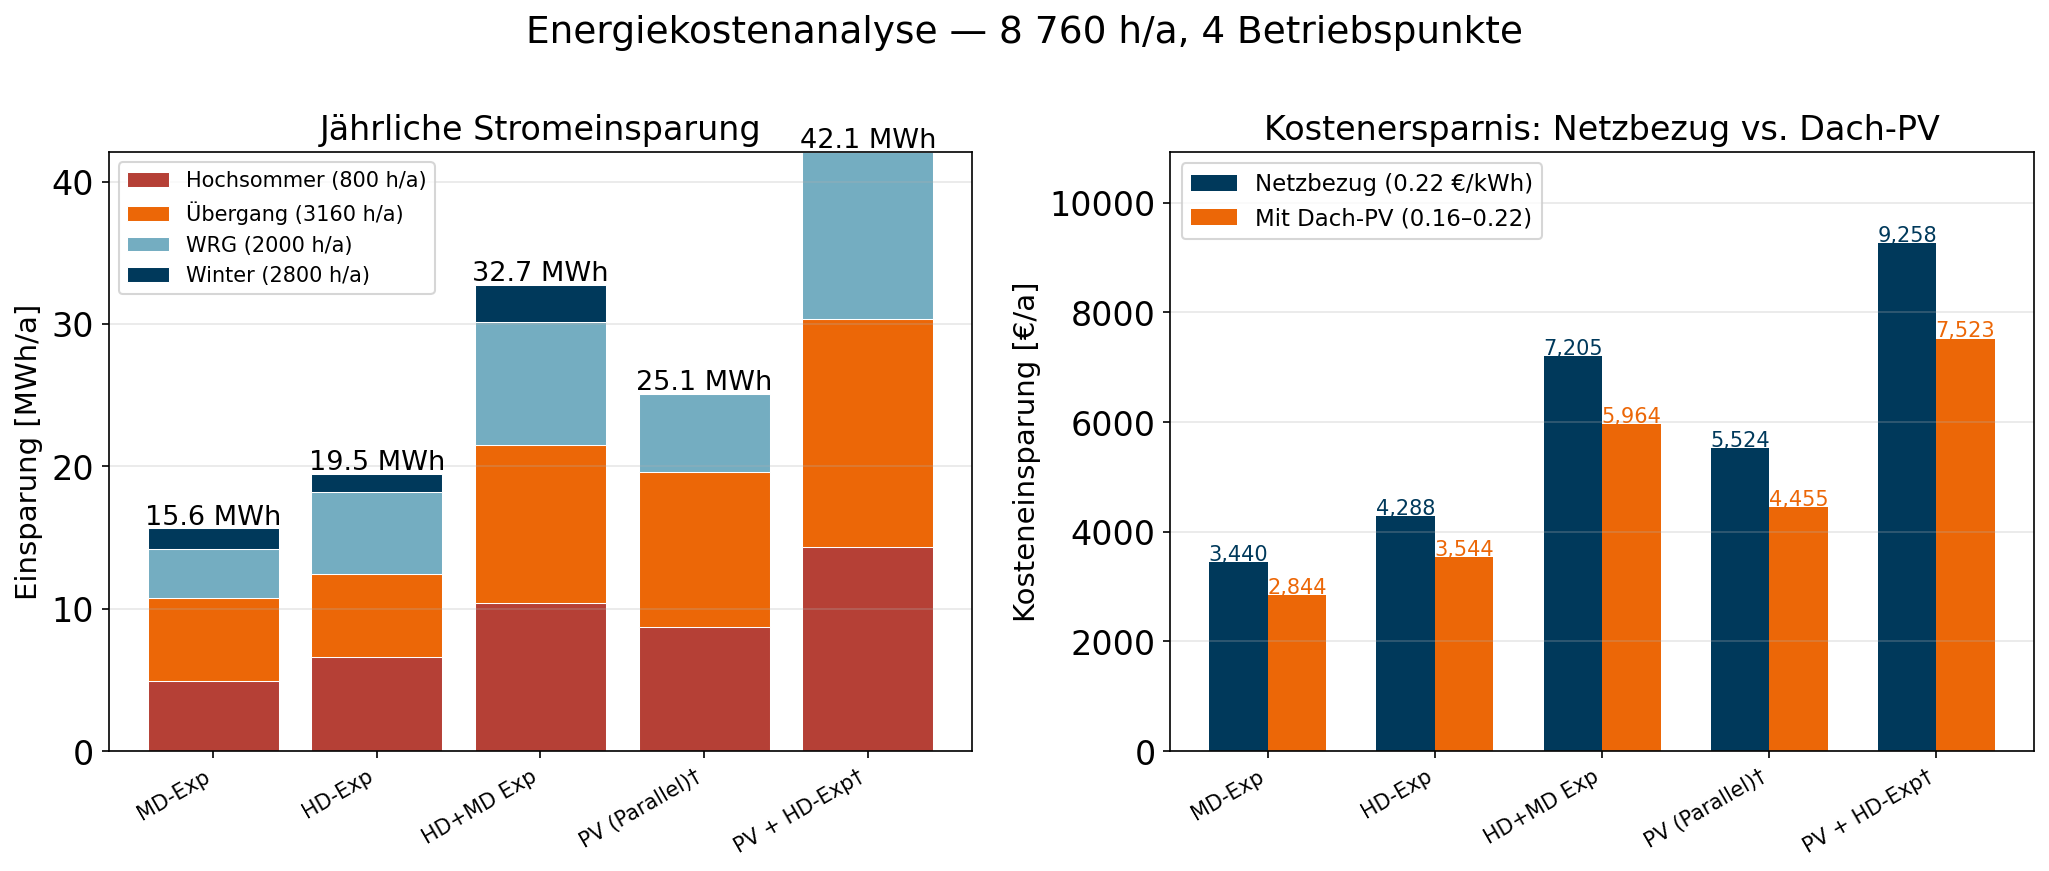

In [17]:
# Energiekostenvisualisierung — Flat vs. Dach-PV
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cfg_labels = df_energy["Konfiguration"].tolist()
op_colors = {"Hochsommer": ECALIA_RED, "Übergang": ECALIA_ORANGE,
             "WRG-Modus": ECALIA_TEAL, "Winter": ECALIA_BLUE}
# Display names for legend
op_display = {"Hochsommer": "Hochsommer", "Übergang": "Übergang",
              "WRG-Modus": "WRG", "Winter": "Winter"}

# Links: Stacked bar — Einsparung nach Betriebspunkt (kWh, preisunabhängig)
bottom = np.zeros(len(cfg_labels))
for op_name, op_color in op_colors.items():
    vals = [row["_savings_op"].get(op_name, 0) / 1000 for _, row in df_energy.iterrows()]
    ax1.bar(range(len(cfg_labels)), vals, bottom=bottom, color=op_color,
            label=f"{op_display[op_name]} ({HOURS_PER_YEAR[op_name]} h/a)", edgecolor='white', linewidth=0.5)
    bottom += np.array(vals)
for i, (_, row) in enumerate(df_energy.iterrows()):
    ax1.text(i, bottom[i] + 0.3, f"{row['ΔE [MWh/a]']} MWh",
             ha='center', fontsize=13)
ax1.set_xticks(range(len(cfg_labels)))
ax1.set_xticklabels(cfg_labels, rotation=30, ha='right', fontsize=10)
ax1.set_ylabel("Einsparung [MWh/a]", fontsize=14)
ax1.set_title("Jährliche Stromeinsparung", fontsize=16)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.margins(y=0.18)

# Rechts: Kosteneinsparung — Flat vs. Dach-PV (gruppierte Balken)
x = np.arange(len(cfg_labels))
width = 0.35
cost_flat = [row["_cost_flat"] for _, row in df_energy.iterrows()]
cost_pv   = [row["_cost_pv"]   for _, row in df_energy.iterrows()]

bars_flat = ax2.bar(x - width/2, cost_flat, width, color=ECALIA_BLUE, label="Netzbezug (0.22 €/kWh)")
bars_pv   = ax2.bar(x + width/2, cost_pv,   width, color=ECALIA_ORANGE, label="Mit Dach-PV (0.16–0.22)")
for bar, val in zip(bars_flat, cost_flat):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{val:,.0f}", ha='center', fontsize=10, color=ECALIA_BLUE)
for bar, val in zip(bars_pv, cost_pv):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{val:,.0f}", ha='center', fontsize=10, color=ECALIA_ORANGE)
ax2.set_xticks(x)
ax2.set_xticklabels(cfg_labels, rotation=30, ha='right', fontsize=10)
ax2.set_ylabel("Kosteneinsparung [€/a]", fontsize=14)
ax2.set_title("Kostenersparnis: Netzbezug vs. Dach-PV", fontsize=16)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.margins(y=0.18)

fig.suptitle("Energiekostenanalyse — 8 760 h/a, 4 Betriebspunkte", fontsize=18)
fig.tight_layout()
plt.show()

---
## 7. COP-Sensitivität über Zwischendruck

$\mathit{p}_\mathrm{medium}$-Sweep (30–48 bar, Hochsommer) für Baseline vs. MD-Expander (IWT vor Expander). Zusätzlich: Effekt einer TK-Stufe (15 kW bei −30 °C) auf den Gesamt-COP.

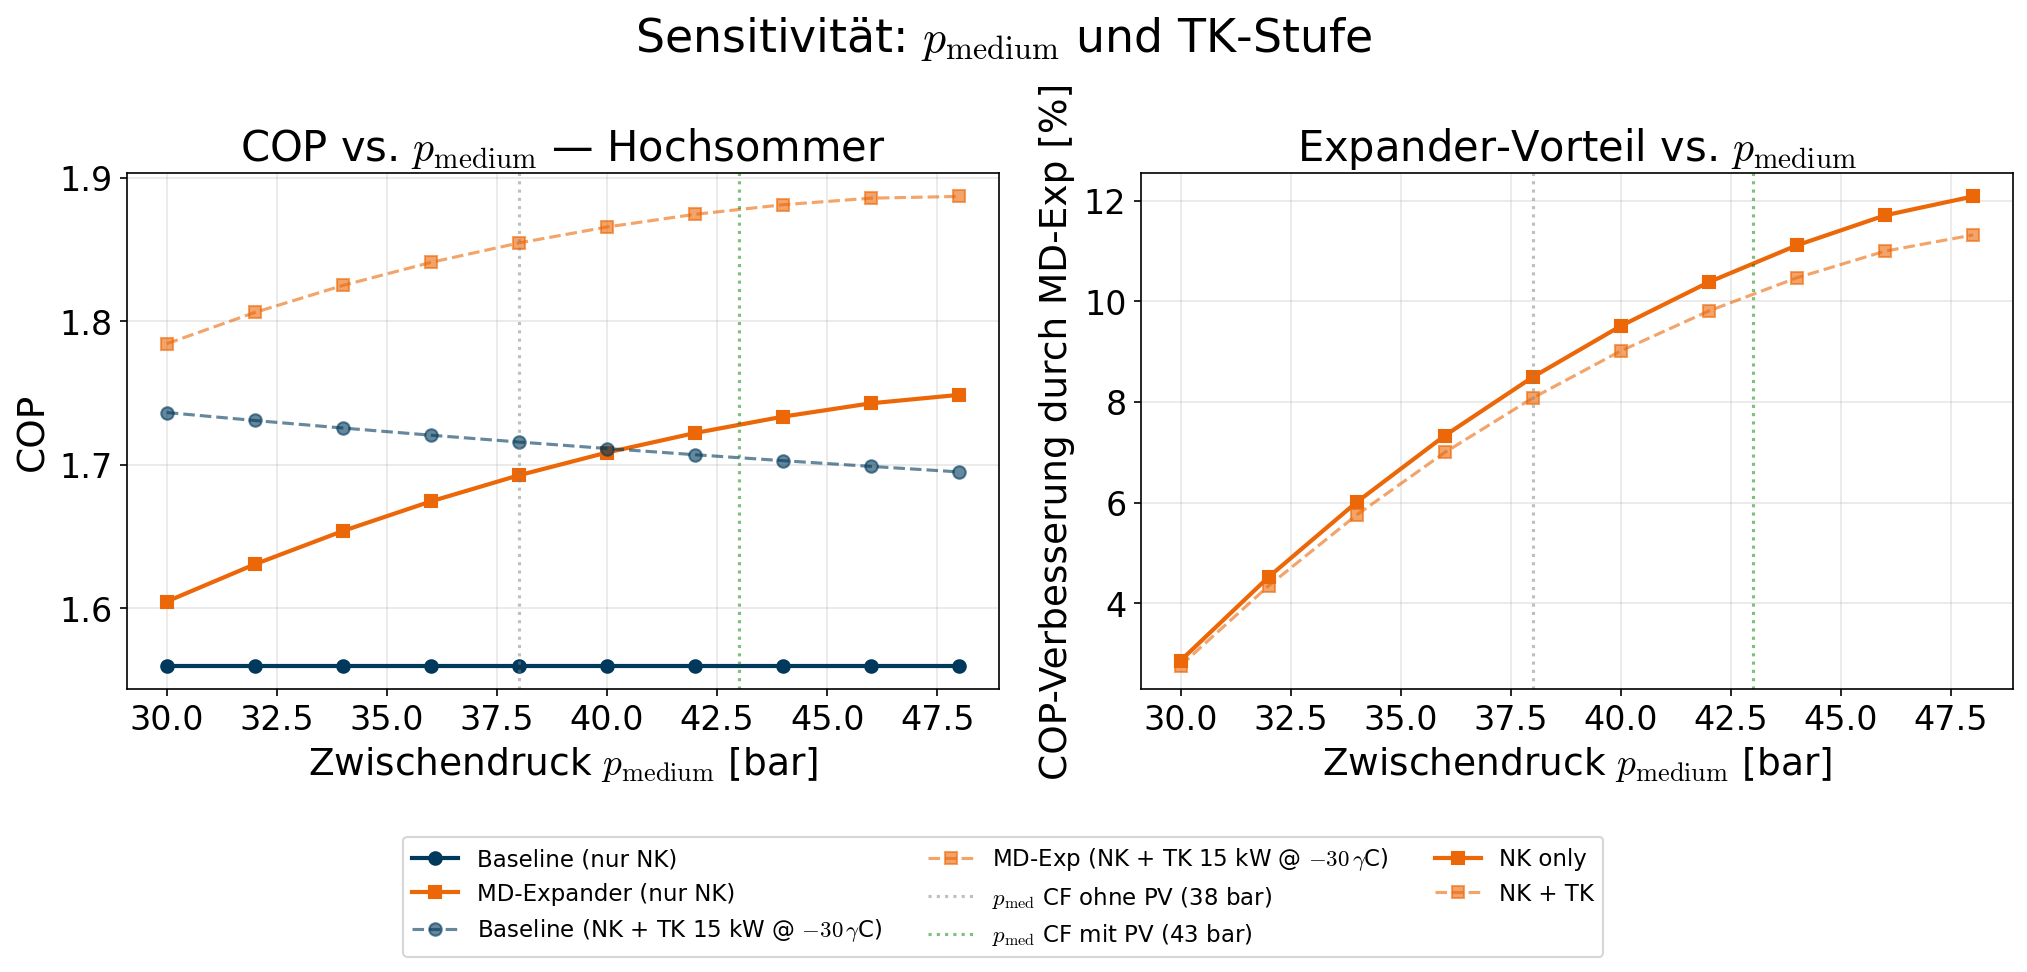

In [18]:
# COP vs. p_medium Sweep (Hochsommer, mit und ohne TK-Stufe)
from copy import deepcopy

ETA_S_HS = ETA_S_CALIBRATED["Hochsommer"]  # 0.691

p_med_range = np.arange(30, 49, 2.0)  # bar
op_base = OP_SUMMER_NO_PV

# TK-Stufe Parameter (typisch: -30 °C, 15 kW)
T_evap_tk = -30.0   # °C
Q0_TK = 15.0        # kW
p_evap_tk = PSI("P", "Q", 1, "T", 273.15 + T_evap_tk, "CO2") / 1e5

# Build result arrays
cop_baseline = np.full(len(p_med_range), np.nan)
cop_md_exp = np.full(len(p_med_range), np.nan)
cop_baseline_tk = np.full(len(p_med_range), np.nan)
cop_md_exp_tk = np.full(len(p_med_range), np.nan)

for i, p_med in enumerate(p_med_range):
    for cfg_key, cfg_kw, arr_nk, arr_tk in [
        ("baseline", {}, cop_baseline, cop_baseline_tk),
        ("md_exp", {"expansion_device_fg": "expander", "iwt_position": IWT_POSITION}, cop_md_exp, cop_md_exp_tk),
    ]:
        try:
            op = deepcopy(op_base)
            op.p_medium = float(p_med)
            mdl = CO2BoosterFlashgasIWT(compressor_efficiency=ETA_S_HS,
                                         expander_efficiency=ETA_E, **cfg_kw)
            mdl.setup_network(iterinfo=False)
            mdl.set_boundary_conditions(op=op)
            mdl.solve()
            if mdl.converged:
                cop_nk = mdl.calculate_cop_cooling()
                P_nk = sum(d['P_kW'] for d in mdl.get_power_breakdown().values())
                arr_nk[i] = cop_nk

                # TK stage estimate: compressor p_evap_tk → p_med
                h_tk_in = PSI("H", "Q", 1, "T", 273.15 + T_evap_tk, "CO2") / 1e3
                s_tk_in = PSI("S", "Q", 1, "T", 273.15 + T_evap_tk, "CO2")
                h_tk_out_s = PSI("H", "S", s_tk_in, "P", float(p_med) * 1e5, "CO2") / 1e3
                h_tk_out = h_tk_in + (h_tk_out_s - h_tk_in) / ETA_S_HS
                h_tk_liq = PSI("H", "Q", 0, "P", p_evap_tk * 1e5, "CO2") / 1e3
                m_tk_kg_s = Q0_TK / (h_tk_in - h_tk_liq)
                W_tk = abs(m_tk_kg_s) * (h_tk_out - h_tk_in)
                arr_tk[i] = (op.Q0_NK + Q0_TK) / (abs(P_nk) + abs(W_tk))
        except Exception:
            pass  # stays NaN

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(p_med_range, cop_baseline, 'o-', color=ECALIA_BLUE,
         label="Baseline (nur NK)", linewidth=2)
ax1.plot(p_med_range, cop_md_exp, 's-', color=ECALIA_ORANGE,
         label="MD-Expander (nur NK)", linewidth=2)
ax1.plot(p_med_range, cop_baseline_tk, 'o--', color=ECALIA_BLUE,
         alpha=0.6, label=r"Baseline (NK + TK 15 kW @ $-30\,°$C)")
ax1.plot(p_med_range, cop_md_exp_tk, 's--', color=ECALIA_ORANGE,
         alpha=0.6, label=r"MD-Exp (NK + TK 15 kW @ $-30\,°$C)")
ax1.axvline(x=38, color='gray', linestyle=':', alpha=0.5,
            label=r"$p_\mathrm{med}$ CF ohne PV (38 bar)")
ax1.axvline(x=43, color='green', linestyle=':', alpha=0.5,
            label=r"$p_\mathrm{med}$ CF mit PV (43 bar)")
ax1.set_xlabel(r"Zwischendruck $p_\mathrm{medium}$ [bar]")
ax1.set_ylabel("COP")
ax1.set_title(r"COP vs. $p_\mathrm{medium}$ — Hochsommer")
ax1.grid(alpha=0.3)

# COP improvement %
cop_impr = np.where((cop_baseline > 0) & np.isfinite(cop_baseline),
                    (cop_md_exp - cop_baseline) / cop_baseline * 100, np.nan)
cop_impr_tk = np.where((cop_baseline_tk > 0) & np.isfinite(cop_baseline_tk),
                       (cop_md_exp_tk - cop_baseline_tk) / cop_baseline_tk * 100, np.nan)
ax2.plot(p_med_range, cop_impr, 's-', color=ECALIA_ORANGE, linewidth=2, label="NK only")
ax2.plot(p_med_range, cop_impr_tk, 's--', color=ECALIA_ORANGE, alpha=0.6, label="NK + TK")
ax2.axvline(x=38, color='gray', linestyle=':', alpha=0.5,
            label=r"$p_\mathrm{med}$ CF ohne PV (38 bar)")
ax2.axvline(x=43, color='green', linestyle=':', alpha=0.5,
            label=r"$p_\mathrm{med}$ CF mit PV (43 bar)")
ax2.set_xlabel(r"Zwischendruck $p_\mathrm{medium}$ [bar]")
ax2.set_ylabel("COP-Verbesserung durch MD-Exp [%]")
ax2.set_title(r"Expander-Vorteil vs. $p_\mathrm{medium}$")
ax2.grid(alpha=0.3)

fig.suptitle(r"Sensitivität: $p_\mathrm{medium}$ und TK-Stufe", fontsize=22)

# Gemeinsame Legende unterhalb der Diagramme
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# Combine unique handles (ax1 has all 6 entries, ax2 has a subset)
all_handles, all_labels = handles1, labels1
for h, l in zip(handles2, labels2):
    if l not in all_labels:
        all_handles.append(h)
        all_labels.append(l)
fig.legend(all_handles, all_labels, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()